In [1]:
import pandas  as pd
diabetes_risk = pd.read_csv("diabetes_risk_dataset.csv", index_col=0)
diabetes_risk.head()

,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
Patient_ID,,,,,,,,,,,,,,,,,,
1,77,Female,33.8,154,93,12.1,5.2,242,194,Low,2169,78.4,8.1,4,No,101.1,52.3,Prediabetes
2,54,Male,19.2,123,94,4.6,5.4,212,76,High,1881,16.5,6.6,3,No,60.0,3.7,Low Risk
3,25,Male,33.7,141,150,10.8,6.9,247,221,Low,2811,147.9,6.7,10,Yes,114.7,87.3,High Risk
4,23,Female,32.8,140,145,11.6,6.8,195,193,Low,2826,98.3,4.4,9,Yes,96.6,76.1,High Risk
5,70,Male,33.7,165,90,18.3,5.6,217,170,Moderate,2610,65.8,9.1,5,Yes,107.4,47.7,Prediabetes


In [2]:
diabetes_risk.describe(include=['int', 'float', 'object'])

,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
count,6000.000000,6000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000,6000.000000,6000.000000,6000.000000,6000.000000,6000,6000.000000,6000.000000,6000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,2,NaN,NaN,3
top,NaN,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN,NaN,No,NaN,NaN,Low Risk
freq,NaN,3051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3181,NaN,NaN,NaN,NaN,4838,NaN,NaN,2602
mean,52.230667,NaN,32.939667,144.482500,106.105500,15.080333,5.784583,217.490667,177.351500,NaN,2479.547000,66.555733,6.998700,5.086500,NaN,105.049600,48.691417,NaN
std,18.757508,NaN,7.510155,17.867248,31.213994,9.245581,0.956614,24.888595,51.897606,NaN,548.410642,39.576891,1.331378,2.342989,NaN,25.079335,37.242034,NaN
min,20.000000,NaN,16.000000,91.000000,60.000000,2.000000,4.100000,139.000000,50.000000,NaN,1200.000000,0.000000,4.000000,1.000000,NaN,60.000000,0.000000,NaN
25%,36.000000,NaN,26.900000,132.000000,87.000000,7.100000,5.200000,200.000000,137.000000,NaN,2055.000000,35.100000,6.100000,3.000000,NaN,84.700000,12.900000,NaN
50%,53.000000,NaN,32.750000,144.000000,96.000000,13.800000,5.500000,217.000000,173.000000,NaN,2385.000000,58.300000,7.100000,5.000000,NaN,104.600000,43.900000,NaN
75%,68.000000,NaN,38.500000,157.000000,114.000000,21.000000,6.100000,234.000000,213.000000,NaN,2848.250000,89.300000,8.000000,7.000000,NaN,124.200000,88.800000,NaN


In [3]:
diabetes_risk.isnull().sum()

age                           0
gender                        0
bmi                           0
blood_pressure                0
fasting_glucose_level         0
insulin_level                 0
HbA1c_level                   0
cholesterol_level             0
triglycerides_level           0
physical_activity_level       0
daily_calorie_intake          0
sugar_intake_grams_per_day    0
sleep_hours                   0
stress_level                  0
family_history_diabetes       0
waist_circumference_cm        0
diabetes_risk_score           0
diabetes_risk_category        0
dtype: int64

In [4]:
diabetes_risk.duplicated().sum()

np.int64(0)

In [5]:
diabetes_risk = diabetes_risk.drop("diabetes_risk_score", axis=1)
diabetes_risk.head()

,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_category
Patient_ID,,,,,,,,,,,,,,,,,
1,77,Female,33.8,154,93,12.1,5.2,242,194,Low,2169,78.4,8.1,4,No,101.1,Prediabetes
2,54,Male,19.2,123,94,4.6,5.4,212,76,High,1881,16.5,6.6,3,No,60.0,Low Risk
3,25,Male,33.7,141,150,10.8,6.9,247,221,Low,2811,147.9,6.7,10,Yes,114.7,High Risk
4,23,Female,32.8,140,145,11.6,6.8,195,193,Low,2826,98.3,4.4,9,Yes,96.6,High Risk
5,70,Male,33.7,165,90,18.3,5.6,217,170,Moderate,2610,65.8,9.1,5,Yes,107.4,Prediabetes


In [6]:
X = pd.get_dummies(diabetes_risk.drop('diabetes_risk_category', axis=1))
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)
y = diabetes_risk['diabetes_risk_category'].map({'High Risk':2, 'Low Risk':1, 'Prediabetes':0})

In [7]:
X.head()

,age,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,waist_circumference_cm,gender_Female,gender_Male,physical_activity_level_High,physical_activity_level_Low,physical_activity_level_Moderate,family_history_diabetes_No,family_history_diabetes_Yes
Patient_ID,,,,,,,,,,,,,,,,,,,,
1,77,33.8,154,93,12.1,5.2,242,194,2169,78.4,8.1,4,101.1,1,0,0,1,0,1,0
2,54,19.2,123,94,4.6,5.4,212,76,1881,16.5,6.6,3,60.0,0,1,1,0,0,1,0
3,25,33.7,141,150,10.8,6.9,247,221,2811,147.9,6.7,10,114.7,0,1,0,1,0,0,1
4,23,32.8,140,145,11.6,6.8,195,193,2826,98.3,4.4,9,96.6,1,0,0,1,0,0,1
5,70,33.7,165,90,18.3,5.6,217,170,2610,65.8,9.1,5,107.4,0,1,0,0,1,0,1


In [8]:
y.head()

Patient_ID
1    0
2    1
3    2
4    2
5    0
Name: diabetes_risk_category, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = (train_test_split(X, y, test_size=20, random_state=30))

print("Training features:", X_train.shape, y_train.shape)
print("Testing features:", X_test.shape, y_test.shape)

Training features: (5980, 20) (5980,)
Testing features: (20, 20) (20,)


In [10]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=8, random_state=2)
tree.fit(X_train, y_train)
score = tree.score(X_test, y_test)
print("Score:", score)

Score: 0.9


<Axes: >

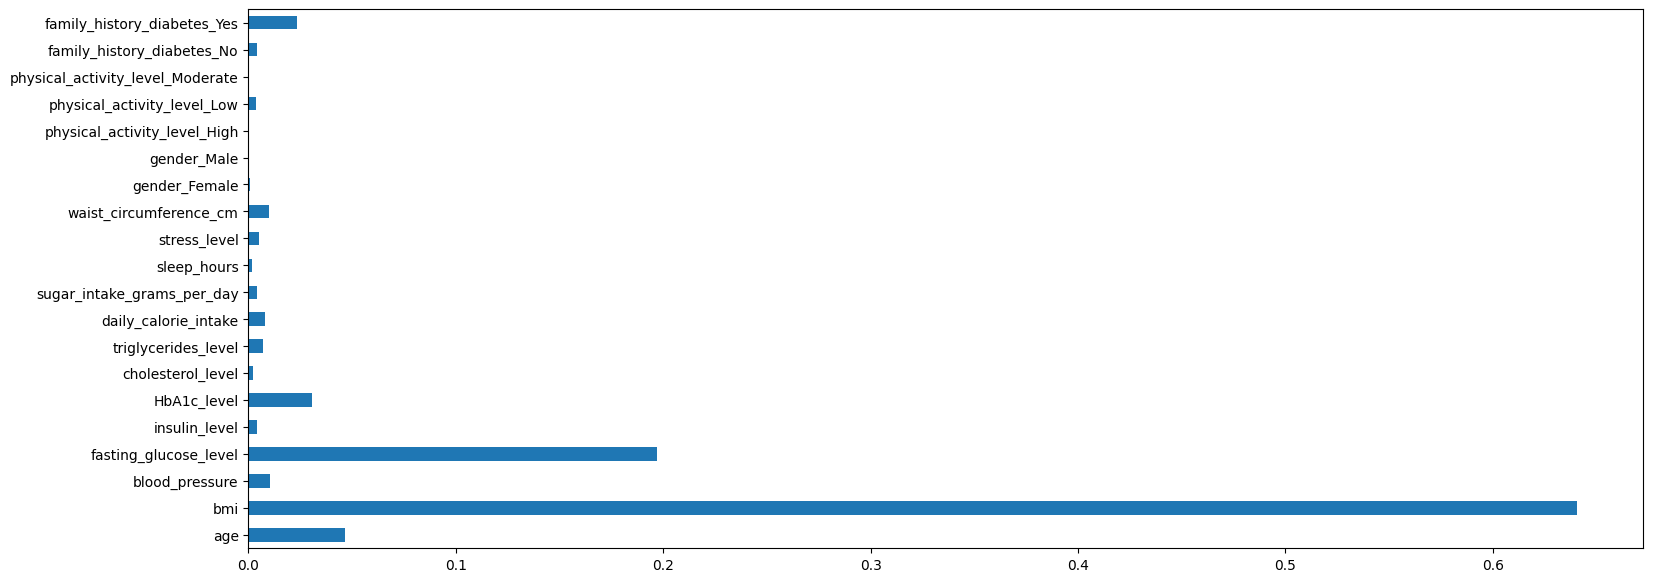

In [11]:
pd.Series(tree.feature_importances_, index=X.columns).plot.barh(figsize=(18,7))

# Dummy Classifier

In [12]:
from sklearn.dummy import DummyClassifier
for strategy in ['most_frequent', 'stratified', 'prior', 'uniform']:
    dummy = DummyClassifier(strategy=strategy, random_state=2)
    dummy.fit(X_train, y_train)
    score = dummy.score(X_test, y_test)
    print("{:<15} | score = {:.3f}".format(strategy, score))

most_frequent   | score = 0.450
stratified      | score = 0.350
prior           | score = 0.450
uniform         | score = 0.050


In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.dummy import DummyClassifier

classifiers = {
    "Dummy"         :DummyClassifier(strategy='uniform', random_state=2),
    "KNN(3)"        :KNeighborsClassifier(3),
    "RBF SVM"       :SVC(gamma=2, C=1),
    "Random Forest" :RandomForestClassifier(max_depth=7, n_estimators=10, max_features=4),
    "Decision Tree" :DecisionTreeClassifier(max_depth=7),
    "Neural Net"    :MLPClassifier(alpha=1),
    "AdaBoost"      :AdaBoostClassifier(),
    "Naive Bayes"   :GaussianNB(),
    "QDA"           :QuadraticDiscriminantAnalysis(reg_param=0.2),
    "Linear SVC"    :LinearSVC(),
    "Linear SVM"    :SVC(kernel='linear'),
    "Guassian Proc" :GaussianProcessClassifier(1.0 * RBF(1.0))
}

In [14]:
from time import time
nfast = 10
head = list(classifiers.items())[:nfast]

for name, classifier in head:
    start = time()
    classifier.fit(X_train, y_train)
    train_time = time()- start
    start = time()
    score = classifier.score(X_test, y_test)
    score_time = time() - start
    print("{:<15} | score = {:.3f}  | time ={:,.3f}s/{:,.3f}s".format(name, score, train_time, score_time))

Dummy           | score = 0.050  | time =0.002s/0.003s
KNN(3)          | score = 0.800  | time =0.007s/6.628s
RBF SVM         | score = 0.450  | time =8.078s/0.038s
Random Forest   | score = 1.000  | time =0.137s/0.008s
Decision Tree   | score = 0.900  | time =0.077s/0.006s
Neural Net      | score = 0.900  | time =1.877s/0.004s
AdaBoost        | score = 0.900  | time =0.796s/0.013s
Naive Bayes     | score = 0.850  | time =0.007s/0.003s
QDA             | score = 0.950  | time =0.038s/0.004s
Linear SVC      | score = 1.000  | time =0.339s/0.004s


In [15]:
tree = DecisionTreeClassifier().fit(X_train, y_train)
pd.Series(tree.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(7)

bmi                       0.578532
fasting_glucose_level     0.187888
age                       0.052531
HbA1c_level               0.031681
waist_circumference_cm    0.020322
blood_pressure            0.017875
daily_calorie_intake      0.014122
dtype: float64

In [16]:
ab = AdaBoostClassifier().fit(X_train, y_train)
pd.Series(ab.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(7)

fasting_glucose_level          0.273821
bmi                            0.264162
waist_circumference_cm         0.105662
age                            0.080590
family_history_diabetes_No     0.064112
blood_pressure                 0.055260
physical_activity_level_Low    0.043216
dtype: float64

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

# best model is 'Linear SVC' with 1.00 output
best_model = classifiers["Linear SVC"]
y_pred = best_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Prediabetes', 'Low Risk', 'High Risk']))

Confusion Matrix:
[[ 1  0  0]
 [ 0  9  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

 Prediabetes       1.00      1.00      1.00         1
    Low Risk       1.00      1.00      1.00         9
   High Risk       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Example: Create a pipeline that scales data then applies SVC
svc_pipeline = make_pipeline(StandardScaler(), SVC(gamma=2, C=1))
svc_pipeline.fit(X_train, y_train)
score = svc_pipeline.score(X_test, y_test)
print("Score:", score)

Score: 0.9


In [19]:
import joblib

# Save your best model (Linear SVC or Random Forest)
joblib.dump(best_model, 'diabetes_model.pkl')
# Save your feature columns for reference
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']